## Forward model for three PHUs - Toronto, Durham and Ottawa

shape of M is (4, 3, 3, 2720)


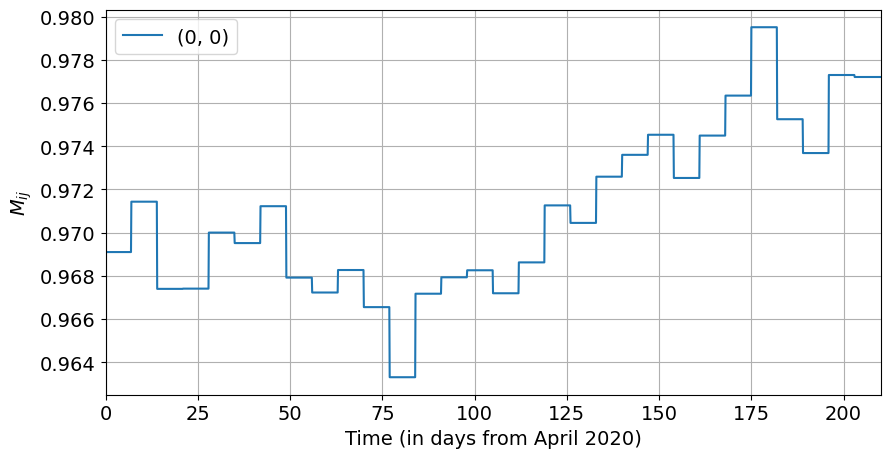

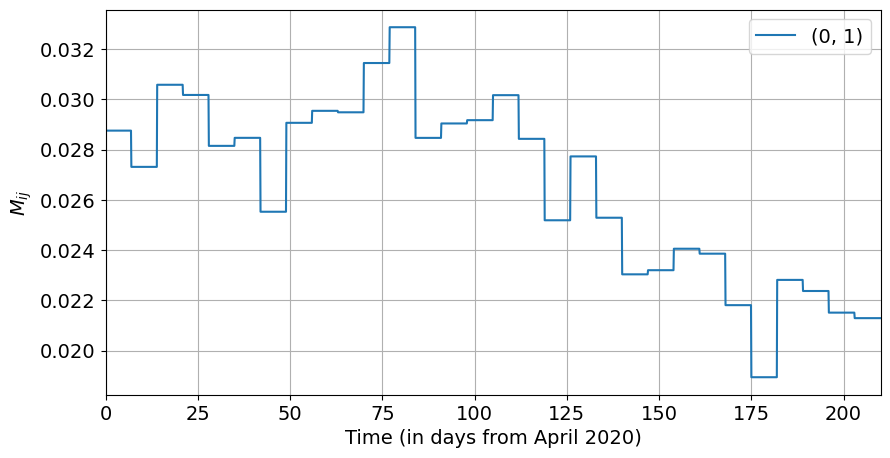

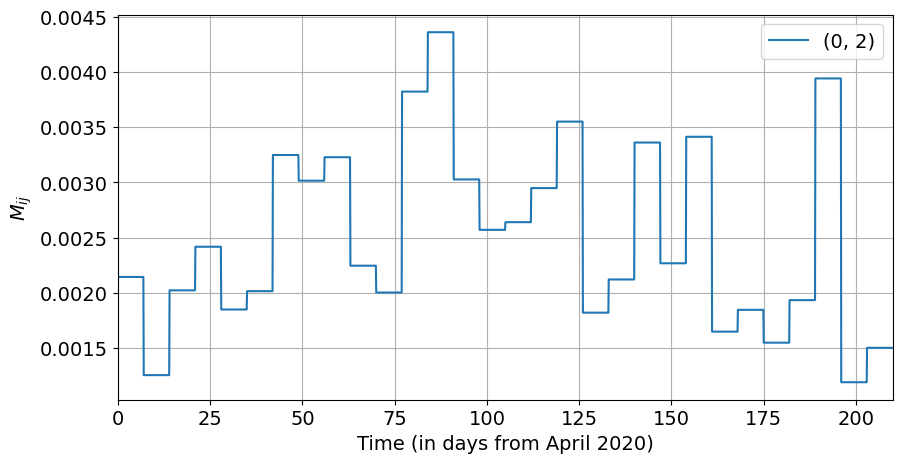

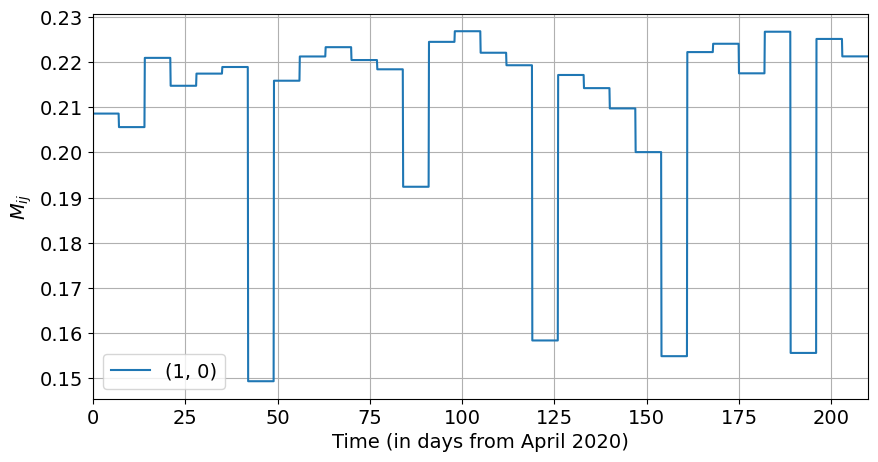

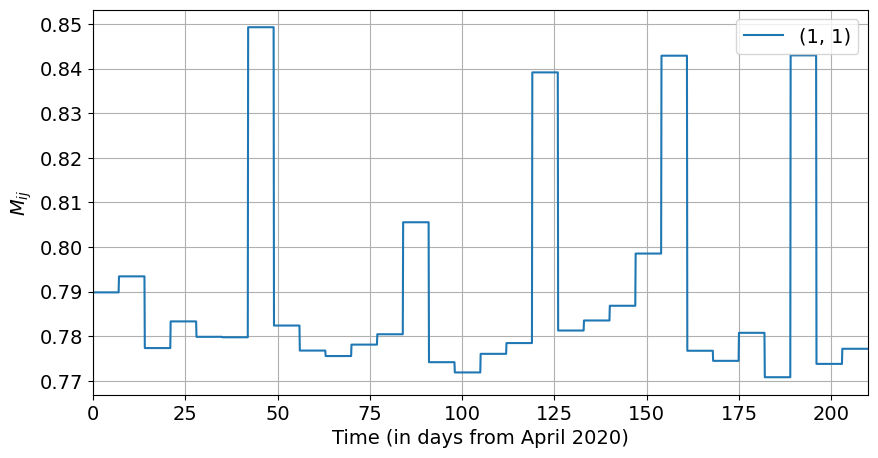

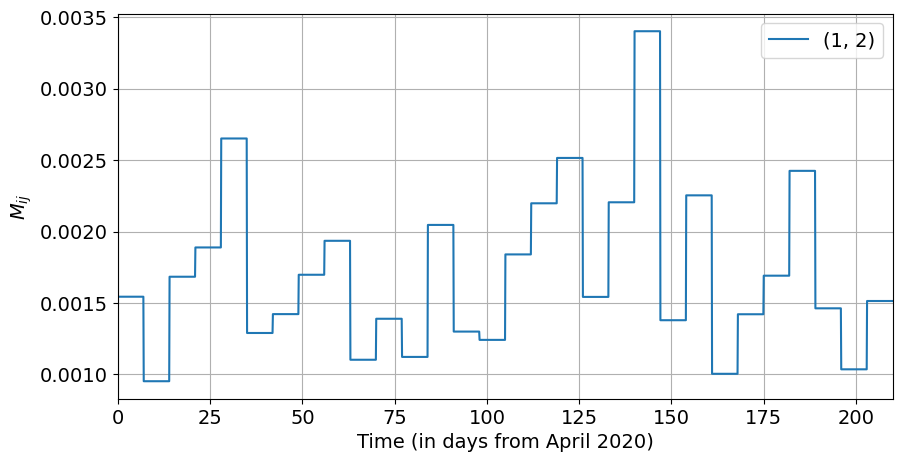

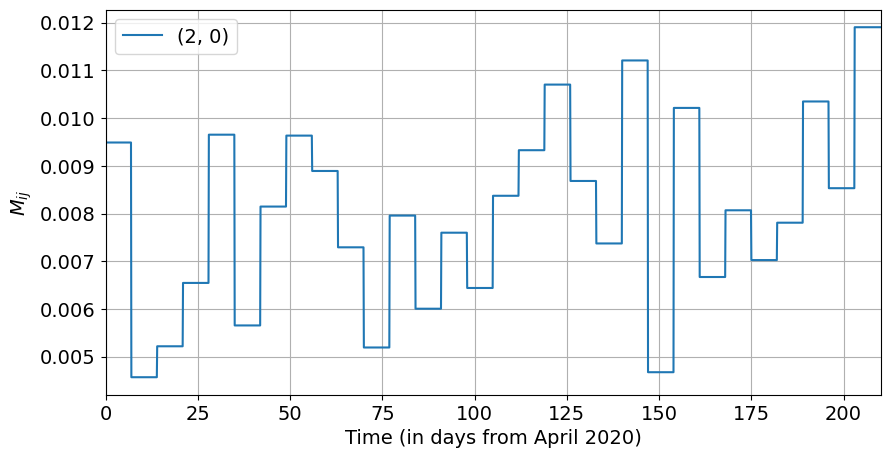

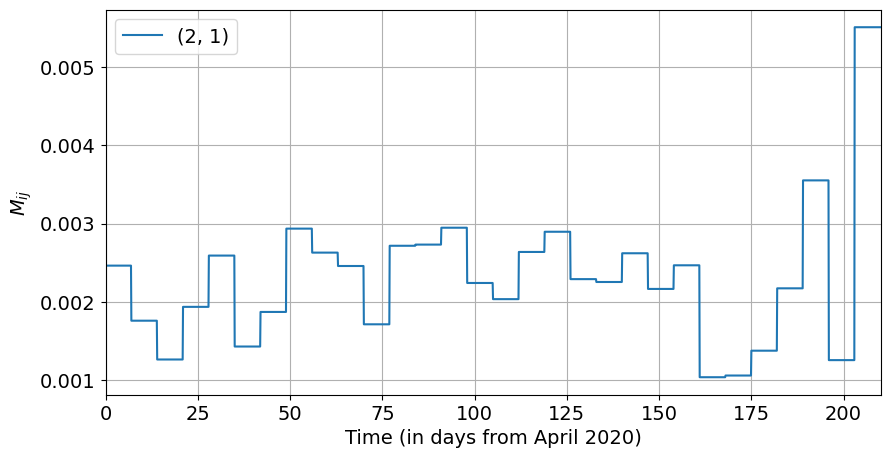

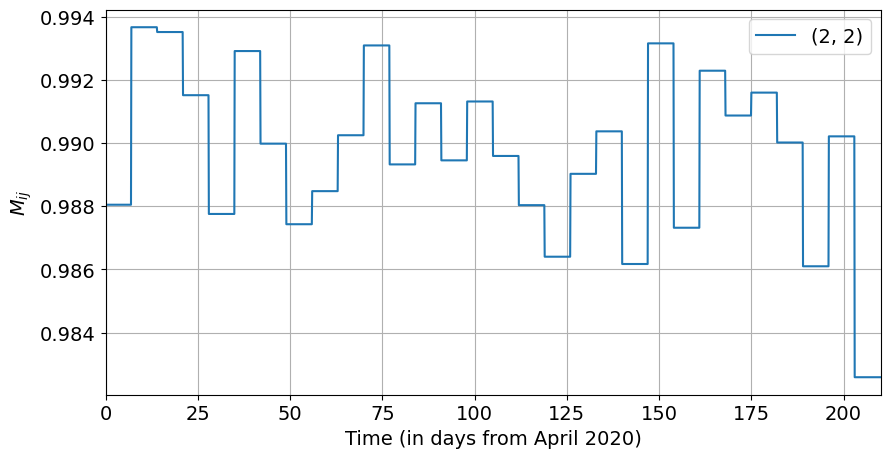

initial infected in PHU1 430.0
total population in PHU1 2794356.0
initial infected in PHU2  94.0
total population in PHU2  696992.0
initial infected in PHU3  136.0
total population in PHU3  1017449.0


In [1]:

import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

dt = 0.1

##### CHANGE HERE #############
### Use the time up to which you need to estimate the parameters of sigmoid
dt = 0.1
tstart = 0
tlim = 210
t = np.arange(tstart, tlim, 1)

### keep it always starting at 0
tmoh = np.arange(0, tlim, dt)

ndiv = 1/dt

N_city = 3


##### CHANGE HERE #############

###### If you have your own data, load it here #######
### Currently loaded infection data from MOH, for April 2020 to March 2021

PHU_path = '/Users/sudhipv/documents/coupled_compartment/PHU_Data/'
datapath = '/Users/sudhipv/documents/coupled_compartment/data/'
figpath = '/Users/sudhipv/documents/coupled_compartment/figs/mle'
Mobility_path = '/Users/sudhipv/documents/coupled_compartment/mobility_tensor'

Data = np.zeros([365,4])

files = os.listdir(PHU_path)

target_file1 = f'{PHU_path}/30-Toronto.csv'
target_file2 = f'{PHU_path}/04-Durham.csv'
target_file3 = f'{PHU_path}/34-York.csv'
target_file4 = f'{PHU_path}/20-Ottawa.csv'

Data[:,0] = np.genfromtxt(target_file1, delimiter=',')
Data[:,1] = np.genfromtxt(target_file2, delimiter=',')
Data[:,2] = np.genfromtxt(target_file3, delimiter=',')
Data[:,3] = np.genfromtxt(target_file4, delimiter=',')


population_by_phu = np.genfromtxt(f'{PHU_path}/population_by_phu.csv', delimiter=',')


# Preallocate compartments
S = np.zeros((len(tmoh),N_city))
E = np.zeros((len(tmoh),N_city))
I = np.zeros((len(tmoh),N_city))
R = np.zeros((len(tmoh),N_city))
D = np.zeros((len(tmoh),N_city))
N = np.zeros((len(tmoh),N_city))


# For noisy synthetic model output
I_model = np.zeros((len(t),N_city))
I_synthetic = np.zeros((len(t),N_city))


# Stratification Tensor M
M = np.zeros((4,N_city,N_city,2720))

print("shape of M is", np.shape(M))


#####################################################################################


#  Below part of code is not well written - It uses the weekly data to generate the daily values 
# of mobility tensor and further saves in each time step. 

# Load the Mobility tensor values based on the Flow matrix

# Week number 13 (starting from 0) is April 6th.
# Week number 37 is Sep 21st.


Mtensor = np.zeros([52,N_city,N_city])

directory_path = f'{Mobility_path}/stochastic_tor_dur_ott'
filesmobility = os.listdir(directory_path)

for ii in range(52):
    
      target_name_part = "Stochastic_matrix"+str(ii)+".dat"
    
      for file in filesmobility:
            if target_name_part == file:
              target_file = file
              break
      else:
        raise FileNotFoundError(f"Could not find any file containing '{target_name_part}'.")

      Mtensor[ii,:,:] = np.genfromtxt(f'{directory_path}/{target_file}', delimiter=' ')


### HARD CODED
mrange = int((272-0)/7) + 1


for w in range(mrange): # 39
   
    sw = 7*w
    
    if(w != mrange-1):
        tsw = np.linspace(sw, sw+6, int((1/dt)*6+1))
    else:
        tsw = np.linspace(sw, sw+5, int((1/dt)*5+1))


    for swk in range(len(tsw)):
        mindex = int((1/dt) * sw + swk)
        M[0,:,:,mindex] = Mtensor[13+w,0:N_city,0:N_city]
        M[1,:,:,mindex] = Mtensor[13+w,0:N_city,0:N_city]
        M[2,:,:,mindex] = Mtensor[13+w,0:N_city,0:N_city]
        M[3,:,:,mindex] = Mtensor[13+w,0:N_city,0:N_city]
        

    tsw2 = np.linspace(sw+6+dt, sw+7, int((1/dt)*1))
    for swk2 in range(1,len(tsw2)):
        mindex2 = mindex + swk2
        M[0,:,:,mindex2] = Mtensor[13+w,0:N_city,0:N_city]
        M[1,:,:,mindex2] = Mtensor[13+w,0:N_city,0:N_city]
        M[2,:,:,mindex2] = Mtensor[13+w,0:N_city,0:N_city]
        M[3,:,:,mindex2] = Mtensor[13+w,0:N_city,0:N_city]


mpl.rcParams.update({'font.size':14})
for i in range(N_city):
    for j in range(N_city):
        plt.figure(i+j+10,figsize=(10,5))
        plt.plot(tmoh, M[0,i,j,0:len(tmoh)], label=f'{i,j}')
        plt.legend(loc='best')
        plt.xlabel('Time (in days from April 2020)')
        plt.xlim([0,tlim])
        plt.ylabel('$M_{ij}$')
        plt.grid()
        plt.show()


#####################################################################################

#####Force of infection , Lambda
L_Force = np.zeros((len(tmoh),N_city))

 
total = np.zeros((N_city))

######## CHANGE HERE #################
total[0] = population_by_phu[29,1]

total[1] = population_by_phu[3,1]

total[2] = population_by_phu[19,1]
#########################

# Initial Conditions
 
E[0,0] = Data[0,0]
I[0,0] = Data[0,0]
######## #################
R[0,0] = 0
D[0,0] = 0
N[0,0] = total[0]
S[0,0] = N[0,0] - E[0,0] - I[0,0] - R[0,0] - D[0,0]

######## CHANGE HERE #################
E[0,1] = Data[0,1]
I[0,1] = Data[0,1]

######## #################
R[0,1] = 0
D[0,1] = 0
N[0,1] = total[1]
S[0,1] = N[0,1] - E[0,1] - I[0,1] - R[0,1] - D[0,1]



E[0,2] = Data[0,3]
I[0,2] = Data[0,3]

######## #################
R[0,2] = 0
D[0,2] = 0
N[0,2] = total[2]
S[0,2] = N[0,2] - E[0,2] - I[0,2] - R[0,2] - D[0,2]


I_model[0,0] = I[0,0]
I_model[0,1] = I[0,1]
I_model[0,2] = I[0,2]


# Model parameters - Taken from Southern Ontario - COVID MBE paper
gamma_e = 1/15
gamma_i = 1/5
gamma_r = 1/11
gamma_d = 1/750

beta_e = np.zeros((len(tmoh),N_city)) 
beta_i = np.zeros((len(tmoh),N_city))

beta_calibrated = np.zeros((len(tmoh),N_city))


print("initial infected in PHU1",I[0,0])

print("total population in PHU1",total[0])

print("initial infected in PHU2 ",I[0,1])

print("total population in PHU2 ",total[1])


print("initial infected in PHU3 ",I[0,2])

print("total population in PHU3 ",total[2])

#### PEEL - 234 , 1451022

#### Toronto - 430 , 2794356

### York - 212, 1173334

### Durham - 94   - 696992


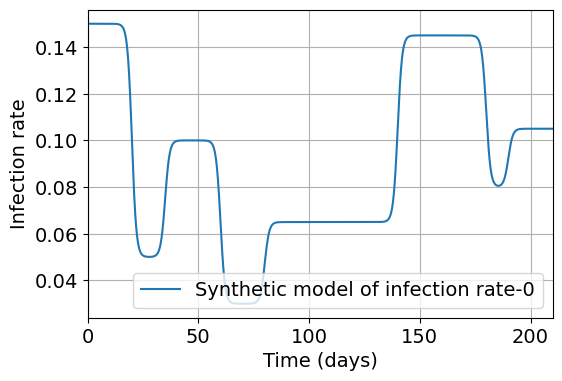

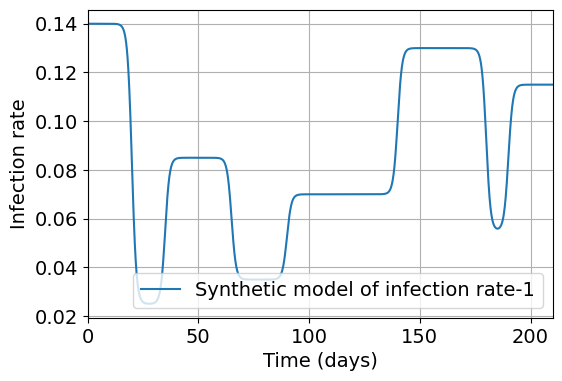

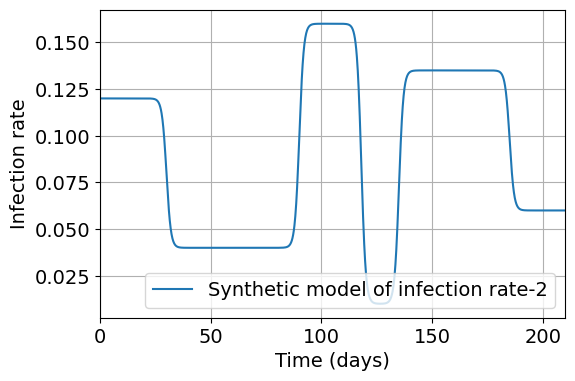

In [2]:

### UNCOMMNET THE RESPECTIVE PARAMETERS WHICH YOU ARE ESTIMATING

### FIRST INDEX REFERES TO THE PARAMETER AND SECOND INDEX TO THE PHU NUMBER
############ Model Parameters for generating Synthetic Data ####################

# original    
a01 =   0.15
a11 =  -0.1
t11 =  20
a21 =   0.05
t21 =  35
a31 =   -0.07
t31 = 60
a41 =  0.035
t41 = 80
a51 =  0.08
t51 = 140
a61 =  -0.065
t61 = 180
a71 =  0.025
t71 = 190
a81 =  -0.015
t81 = 230  


beta_i[:,0] = a01 + a11/(1 + np.exp((t11-tmoh))) \
+ a21/(1 + np.exp((t21-tmoh))) \
+ a31/(1 + np.exp((t31-tmoh))) \
+ a41/(1 + np.exp((t41-tmoh))) \
+ a51/(1 + np.exp((t51-tmoh))) \
+ a61/(1 + np.exp((t61-tmoh))) \
+ a71/(1 + np.exp((t71-tmoh))) \
+ a81/(1 + np.exp((t81-tmoh))) 

beta_e[:,0] = beta_i[:,0]


################### Durham ##########################################################


# Original
a02 =   0.14
a12 =  -0.115
t12 =  20
a22 =   0.06
t22 =  35
a32 =   -0.05
t32 = 65
a42 =  0.035
t42 = 90
a52 =  0.06
t52 = 140
a62 =  -0.075
t62 = 180
a72 =  0.06
t72 = 190
a82 =  -0.025
t82 = 250


beta_i[:,1] = a02  + a12/(1 + np.exp((t12-tmoh))) \
+ a22/(1 + np.exp((t22-tmoh))) \
+ a32/(1 + np.exp((t32-tmoh))) \
+ a42/(1 + np.exp((t42-tmoh))) \
+ a52/(1 + np.exp((t52-tmoh))) \
+ a62/(1 + np.exp((t62-tmoh))) \
+ a72/(1 + np.exp((t72-tmoh))) \
+ a82/(1 + np.exp((t82-tmoh))) 

beta_e[:,1] = beta_i[:,1]


###################### Ottawa ######################################################

a03 =   0.12
a13 =  -0.08
t13 =  30
a23 =   0.12
t23 =  90
a33 =   -0.15
t33 = 118
a43 =  0.125
t43 = 135
a53 =  -0.075
t53 = 185
a63 =  0.035
t63 = 235

beta_i[:,2] = a03 + a13/(1 + np.exp((t13-tmoh))) +  a23/(1 + np.exp((t23-tmoh))) + a33/(1 + np.exp((t33-tmoh))) + a43/(1 + np.exp((t43-tmoh))) + a53/(1 + np.exp((t53-tmoh))) + a63/(1 + np.exp((t63-tmoh)))
beta_e[:,2] = beta_i[:,2]



for ff in range(N_city):
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.set_xlim([0,tlim])
    ax2.set_xlabel('Time (days)')
    ax2.set_ylabel('Infection rate') 
    ax2.grid()
    plt.plot(tmoh, beta_i[:,ff], label=f'Synthetic model of infection rate-{ff}')
    # plt.plot(tmoh, beta_i[:,1], label='Synthetic model of infection rate-2')
    ax2.legend(loc='lower right')
    # plt.savefig('./figs/beta_true.pdf',  bbox_inches='tight')
    plt.show()




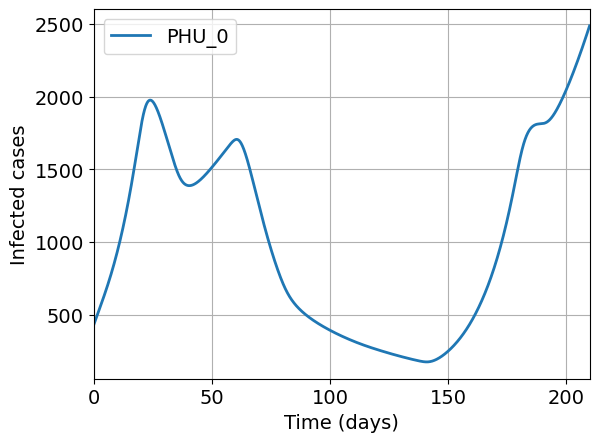

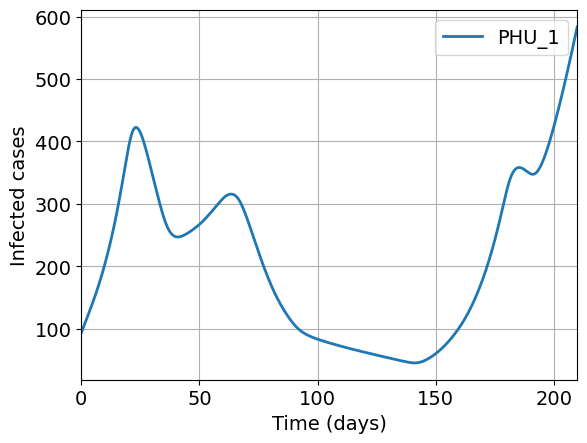

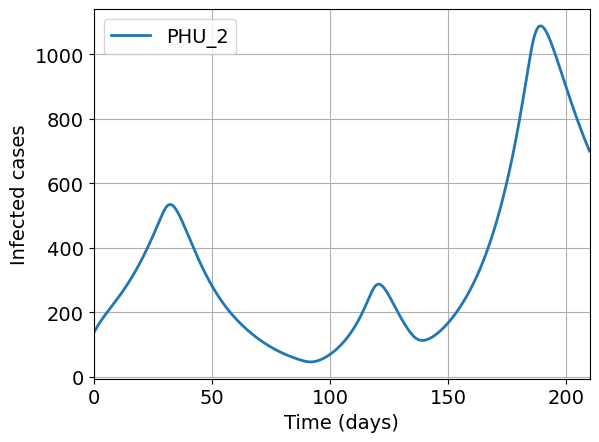

In [3]:
##### LOAD PRE GENERATED NOISY DATA #########

idxmoh = 0

#### With mobility tensor   

for kk in range(1,len(tmoh)):

    for gg in range(0,N_city):

        L_sum = 0
        for ll in range(0,N_city):

            Nlm = 0
            L_cityinf = 0
            
            for mm in range(0,N_city):
                Nlm =  Nlm + M[0,mm,ll,kk-1] * S[kk-1,mm] +  M[1,mm,ll,kk-1] * E[kk-1,mm] + M[2,mm,ll,kk-1] * I[kk-1,mm] + M[3,mm,ll,kk-1] * R[kk-1,mm]


                L_cityinf = L_cityinf + (beta_e[kk-1,ll] * M[1,mm,ll,kk-1] * E[kk-1,mm] + beta_i[kk-1,ll] * M[2,mm,ll,kk-1] * I[kk-1,mm])


            L_sum = L_sum + (M[0,gg,ll,kk-1] * L_cityinf)/Nlm


        L_Force[kk-1,gg] = L_sum


        S[kk,gg] = S[kk-1,gg] - dt*(L_Force[kk-1,gg]*S[kk-1,gg])
        E[kk,gg] = E[kk-1,gg] + dt*(L_Force[kk-1,gg]*S[kk-1,gg] - (gamma_i + gamma_e)*E[kk-1,gg])
        I[kk,gg] = I[kk-1,gg] + dt*(gamma_i*E[kk-1,gg] - (gamma_r + gamma_d)*I[kk-1,gg])
        R[kk,gg] = R[kk-1,gg] + dt*(gamma_e*E[kk-1,gg] + gamma_r*I[kk-1,gg])
        D[kk,gg] = D[kk-1,gg] + dt*(gamma_d*I[kk-1,gg])
        N[kk,gg] = S[kk,gg] +  E[kk,gg] + I[kk,gg] + R[kk,gg]


        # if( kk%ndiv == 0):
        #     idxmoh = int(kk/ndiv)
        #     if(tstart != 0):
        #         if(idxmoh >= tstart and idxmoh < tlim):
        #             I_model[idxmoh-tstart,gg] = I[kk,gg]
        #     else:
        #         idxmoh = int(kk/ndiv)
        #         I_model[idxmoh,gg] = I[kk,gg]

        

for hh in range(N_city):
    plt.plot(tmoh, I[:,hh], '-',linewidth=2, label=f'PHU_{hh}')
    plt.legend(loc='best')
    plt.xlabel('Time (days)')
    plt.xlim([0,tlim])
    plt.ylabel('Infected cases')
    plt.grid()
    # plt.savefig(filepath)
    plt.show()



